# Statewide races

Note: 'current' results are currently pointing to 2022 results, so as to be able to verify the model is working.

In [4]:
# Prep

import model

import pandas as pd

regions_nonmetro = pd.read_csv('./regions/regions_nonmetro.csv', index_col='County')
regions_nonmetro

,Region,Subregion
County,,
Banks,East,Outer East Georgia
Barrow,East,Metro Athens
Clarke,East,Metro Athens
Elbert,East,Outer East Georgia
Franklin,East,Outer East Georgia
...,...,...
Heard,West,Newnan-LaGrange
Meriwether,West,Newnan-LaGrange
Paulding,West,Carrollton-Paulding


Text(0.5, 1.0, 'Non-Metro Regions')

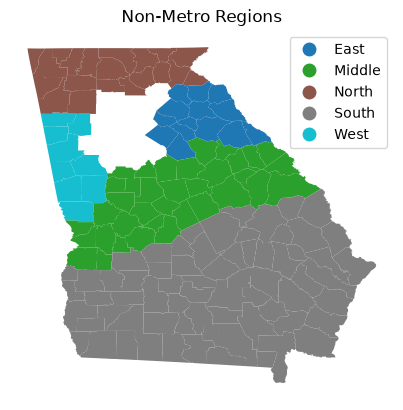

In [5]:
import utils

counties = utils.import_county_map()
counties['Region'] = regions_nonmetro['Region']
regions = counties['Region'].unique()
ax = counties.plot(column='Region', legend=True)
ax.set_axis_off()
ax.set_title('Non-Metro Regions')

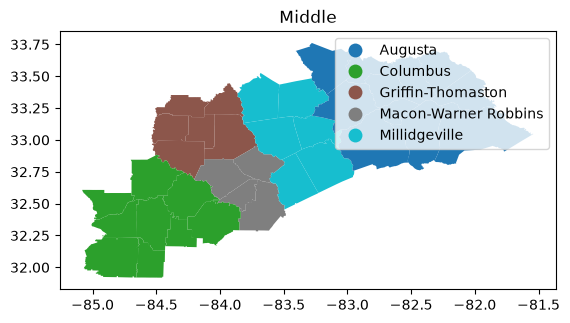

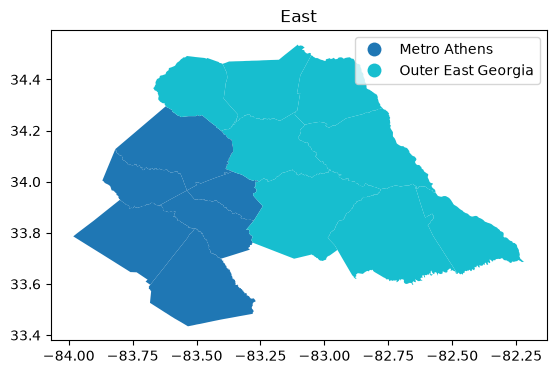

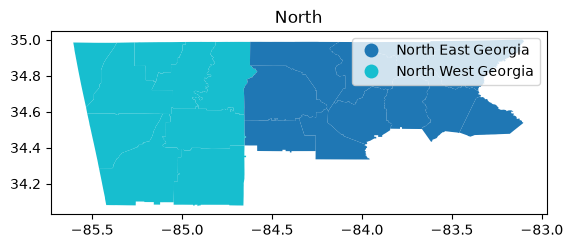

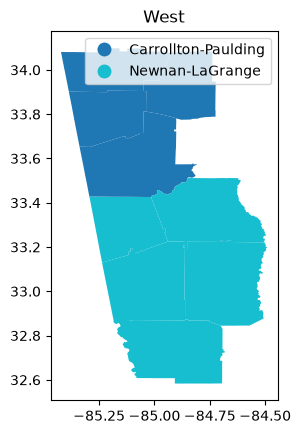

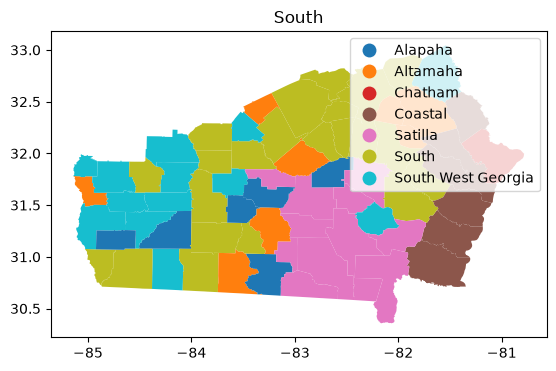

In [6]:
counties['Subregion'] = regions_nonmetro['Subregion']

for region in regions:
    if str(region) == 'nan':
        continue
    counties_f = counties[counties['Region'] == region]
    ax = counties_f.plot(column='Subregion', legend=True)
    ax.set_title(region)


In [7]:
def import_historical(year, office):
    return pd.read_csv(f'./data/{year}_{office}.csv', index_col=['County', 'Vote Method'])

In [8]:
def display_single_results(df):
    res = df.sum()
    res = pd.DataFrame(res, columns=['Votes'])
    res = res.sort_values(by='Votes', ascending=False)
    res['Share'] = (res['Votes'] / res['Votes'].sum() * 100)
    return res

# Import Results

In [9]:
import pandas as pd

# Contains some code that needs to be used by other notebooks.
import data

# 2022 election data for now
results_data = data.compile('./export-2022NovGen.json', data.statewide_races_2022, '2022') 
results_data

{'Governor':                             Brian Kemp (I) (Rep)  Stacey Abrams (Dem)  \
 County    Vote Method                                                   
 Appling   Election Day                    2647.0                363.0   
           Advance Voting                  2654.0                633.0   
           Absentee by Mail                 250.0                135.0   
           Provisional                        1.0                  0.0   
 Atkinson  Election Day                     889.0                176.0   
 ...                                          ...                  ...   
 Wilkinson Provisional                        0.0                  1.0   
 Worth     Election Day                    3292.0                623.0   
           Advance Voting                  2232.0                924.0   
           Absentee by Mail                 119.0                167.0   
           Provisional                        6.0                  2.0   
 
                        

## Governor

In [10]:
prev = import_historical(2018, 'governor')
prev_table = display_single_results(prev)
prev_table

,Votes,Share
BRIAN KEMP (REP),1978408,50.221967
STACEY ABRAMS (DEM),1923685,48.832821
TED METZ (LIB),37235,0.945212


In [11]:
kemp2022 = 'Brian Kemp (I) (Rep)'
abrams2022 = 'Stacey Abrams (Dem)'
hazel2022 = 'Shane Hazel (Lib)'

winning_cand = prev_table.loc['BRIAN KEMP  (REP)'] # prev[kemp2022]
runner_up = prev_table.loc['STACEY ABRAMS  (DEM)'] # prev[abrams2022]
meta = {
    'Margin': winning_cand['Votes'] - runner_up['Votes'],
    'Margin (points)': winning_cand['Share'] - runner_up['Share'],
    'Swing required for Dem gain': 50 - runner_up['Share']
}
pd.Series(meta)


Margin                         54723.000000
Margin (points)                    1.389146
Swing required for Dem gain        1.167179
dtype: float64

In [17]:
curr = results_data['Governor']
results_table = display_single_results(curr)

results_table.loc[kemp2022, 'Swing'] = results_table.loc[kemp2022, 'Share'] - prev_table.loc['BRIAN KEMP  (REP)', 'Share']
results_table.loc[abrams2022, 'Swing'] = results_table.loc[abrams2022, 'Share'] - prev_table.loc['STACEY ABRAMS  (DEM)', 'Share']
results_table.loc[hazel2022, 'Swing'] = results_table.loc[hazel2022, 'Share'] - prev_table.loc['TED METZ (LIB)', 'Share']

#jackson2026 = 'Rick Jackson (Rep)'
#bottoms2026 = 'Keisha Lance Bottoms (Dem)'
#results_table.loc[jackson2026, 'Swing'] = results_table.loc[jackson2026, 'Share'] - prev.loc[kemp2022, 'Share']
#results_table.loc[bottoms2026, 'Swing'] = results_table.loc[bottoms2026, 'Share'] - prev.loc[abrams2022, 'Share']

results_table

,Votes,Share,Swing
Brian Kemp (I) (Rep),2111572.0,53.411436,3.189470
Stacey Abrams (Dem),1813673.0,45.876191,-2.956630
Shane Hazel (Lib),28163.0,0.712373,-0.232839


In [13]:
votes = results_table['Votes'].tolist()
majority = votes[0] - votes[1]
majority

297899.0

In [18]:
import matplotlib.pyplot as plt

votes_in_doubt = 297899
total_projected = results_table['Votes'].sum() + votes_in_doubt
ranges = pd.DataFrame(results_table, columns=['Votes', 'Share'])
ranges['Min. Share'] = ranges['Votes'] / total_projected * 100
ranges['Max. Share'] = (ranges['Votes'] + votes_in_doubt) / total_projected * 100
ranges['Min. Del'] = ranges['Share'] - ranges['Min. Share']
ranges['Max. Del'] = ranges['Max. Share'] - ranges['Share']
ranges

,Votes,Share,Min. Share,Max. Share,Min. Del,Max. Del
Brian Kemp (I) (Rep),2111572.0,53.411436,49.668772,56.676006,3.742664,3.264569
Stacey Abrams (Dem),1813673.0,45.876191,42.661539,49.668772,3.214652,3.792582
Shane Hazel (Lib),28163.0,0.712373,0.662455,7.669688,0.049918,6.957316


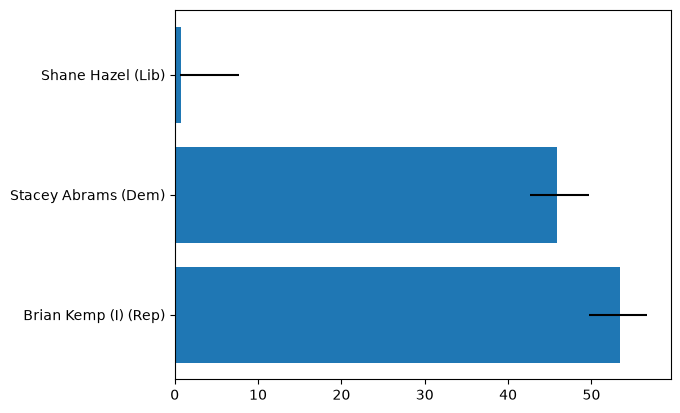

In [15]:
plt.barh(ranges.index, ranges['Share'], xerr=[ranges['Min. Del'], ranges['Max. Del']], )
plt.show()

In [69]:
prev_votes_county = pd.DataFrame(prev)
prev_cands = prev_votes_county.columns
prev_votes_county = prev_votes_county.groupby(level='County').agg(sum)
prev_votes_county['Total Votes'] = prev_votes_county.index.map(lambda i: prev_votes_county.loc[i].sum())
prev_shares = pd.DataFrame(prev_votes_county)
prev_shares['Region'] = counties['Region']
prev_shares = prev_shares.groupby('Region').agg(sum)
for cand in prev_cands:
    prev_shares[cand] = prev_shares[cand] / prev_shares['Total Votes'] * 100

index = pd.MultiIndex.from_tuples([y for x in [[(reg, 'Current'), (reg, 'Projection')] for reg in regions] for y in x], names=('Region', 'Model'))
curr_votes_county = pd.DataFrame(curr)
curr_cands = curr_votes_county.columns
stwd_proj = pd.Series(0, index=curr_cands)
curr_votes_county['Total Votes'] = curr_votes_county.index.map(lambda i: curr_votes_county.loc[i].sum())
curr_votes_county = curr_votes_county.groupby(level='County').agg(sum)
curr_shares = pd.DataFrame(curr_votes_county)
curr_shares['Region'] = counties['Region']
curr_shares = curr_shares.groupby('Region').agg(sum)
for cand in curr_cands:
    curr_shares[cand] = curr_shares[cand] / curr_shares['Total Votes'] * 100   
curr_shares = curr_shares.drop(['Total Votes'], axis=1)
curr_shares = pd.concat([curr_shares], axis=1, keys=['Share']).swaplevel(0, 1, 1)
curr_shares[(kemp2022, 'Swing')] = curr_shares[kemp2022, 'Share'] - prev_shares['BRIAN KEMP  (REP)']
curr_shares[(abrams2022, 'Swing')] = curr_shares[abrams2022, 'Share'] - prev_shares['STACEY ABRAMS  (DEM)']
curr_shares[(hazel2022, 'Swing')] = curr_shares[hazel2022, 'Share'] - prev_shares['TED METZ (LIB)']
curr_shares

,Brian Kemp (I) (Rep),Stacey Abrams (Dem),Shane Hazel (Lib),Brian Kemp (I) (Rep),Stacey Abrams (Dem),Shane Hazel (Lib)
,Share,Share,Share,Swing,Swing,Swing
Region,,,,,,
East,69.935425,29.291687,0.772888,3.169854,-2.977983,-0.191871
Middle,55.132689,44.219336,0.647975,3.093292,-2.998469,-0.094823
North,82.235259,16.890704,0.874037,2.700357,-2.543439,-0.156918
South,63.795842,35.596489,0.607669,3.067963,-3.012579,-0.055384
West,71.159447,28.065932,0.774622,1.724333,-1.540970,-0.183363


In [77]:
prev_shares_county = pd.DataFrame(prev_votes_county)
for cand in prev_cands:
    prev_shares_county[cand] = prev_shares_county[cand] / prev_shares_county['Total Votes'] * 100

curr_shares_county = pd.DataFrame(curr_votes_county)
swings_county = pd.DataFrame(index=curr_shares_county.index)
for cand in curr_cands:
    curr_shares_county[cand] = curr_shares_county[cand] / curr_shares_county['Total Votes'] * 100
swings_county[kemp2022] = curr_shares_county[kemp2022] - prev_shares_county['BRIAN KEMP  (REP)']
swings_county[abrams2022] = curr_shares_county[abrams2022] - prev_shares_county['STACEY ABRAMS  (DEM)']

swings_county

,Brian Kemp (I) (Rep),Stacey Abrams (Dem)
County,,
Appling,3.110564,-3.071150
Atkinson,4.287788,-4.465212
Bacon,2.298148,-2.205947
Baker,1.779239,-1.631015
Baldwin,3.770394,-3.759590
...,...,...
Whitfield,5.135506,-5.053392
Wilcox,2.908954,-3.077344
Wilkes,2.456081,-2.367073
